# Battleships AI
Simulated 


### Simple first version
#### Specifications

* Discretized 2d grid, 10x10
actions: 
    * up, down, left, right
    * so 4
* 2 players


##### State vector:
    * posx of player 1
    * posy of player 1
    * posx of player 2
    * posy of player 2
    * position of loot x
    * position of loot y

eg:
> [5,4,2,1,2,4]

##### Q matrix:
    * we will have one for each agent
    * 4 actions, 1,000,000 states

##### Points:
    We spawn a green block on the field, and the agents have to reach it.
    whoever reaches it first gets a point.


In [2]:
import matplotlib.pyplot as plt
import numpy as np  

In [3]:
class Position:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other):
        return Position(self.x + other.x, self.y + other.y)

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __repr__(self):
        return f"({self.x}, {self.y})"
    
class Agent:
    def __init__(self, env, pos, name='Agent'):
        self.env = env
        self.pos = pos
        self.actions = [Position(0,1), Position(0,-1), Position(1,0), Position(-1,0)]        
        self.nstates = len(self.env.states)
        self.nactions = len(self.actions)
        self.history = []
        self.last_history = None

    def init_Q(self, Q_noise=0.1):    
        self.Q = np.ones((self.nstates, self.nactions))
        self.Q_noise = Q_noise
        self.Q *= .5
        
    def set_Q_noise(self, Q_noise):
        self.Q_noise = Q_noise

    def __repr__(self):
        return f'{self.__class__.__name__} at position {self.pos}'

    def move(self, action_idx, state_index):
        self.history.append((state_index, action_idx))

        direction = self.actions[action_idx]
        new_pos = self.pos + direction

        if self.env.is_valid(new_pos):
            self.pos = new_pos

    def get_action(self, state_index):
        return np.argmax(self.Q[state_index] + np.random.randn(self.nactions)*self.Q_noise)
            
    def set_reward_length(self, reward_length):
        self.reward_length = reward_length

    def update_Q(self, reward):
        # reward can be 1, 0. note that not getting a reward, slightly punishes the Q values of that trajectory.

        if reward == 1:
            for state, action in self.history[-self.reward_length:]:
                self.Q[state][action] = (self.Q[state][action]*20 + 1) / 21  #
        else:
            for state, action in self.history[-self.reward_length:]:
                self.Q[state][action] = (self.Q[state][action]*20+0) / 21

class Environment:
    def __init__(self, width, height):
        self.width = width
        self.height = height
        self.agents = []
        self.states = self.get_state_list(len(self.agents))
        self.loot = Position(5,5)
        self.num_games = 0
        self.num_moves_in_game = 0
        self.length_of_games = []
        self.loot_dym = 'dynamic'

    def reset(self):
        self.num_games = 0
        self.num_moves_in_game = 0
        self.length_of_games = []
        self.loot = Position(5,5)
        for agent in self.agents:
            agent.pos = Position(1,1)
            agent.history = []

    def is_valid(self, pos):
        return 0 <= pos.x < self.width and 0 <= pos.y < self.height
    
    def add_agent(self, agent):
        self.agents.append(agent)
        self.states = self.get_state_list(len(self.agents))
        agent.nstates = len(self.states)
        agent.init_Q()

    def get_state_list(self, n_agents=2):
        print('Generating states for', n_agents, 'agents')
        states = []
        if n_agents ==1:
            print('Generating states for 1 agent')
            for p1x in range(self.width):
                for p1y in range(self.height):
                    for lootx in range(self.width):
                        for looty in range(self.height):
                            states.append([p1x,p1y,lootx,looty])
        elif n_agents == 2:
            for p1x in range(self.width):
                for p1y in range(self.height):
                    for p2x in range(self.width):
                        for p2y in range(self.height):
                            for lootx in range(self.width):
                                for looty in range(self.height):
                                    states.append([p1x,p1y,p2x,p2y,lootx,looty])
        print('The total number of states is:', len(states))

        return np.array(states)

    def get_state_index(self, state_short_name):
        idx = np.argmax(np.sum(self.states == np.array(state_short_name), axis=1))
        return idx

    def get_state(self):

        state_short_name = [0,0] * len(self.agents) + [self.loot.x, self.loot.y]
        # state = np.array([[0 for _ in range(self.width)] for _ in range(self.height)])
        state = np.zeros((self.height, self.width))

        for i, agent in enumerate(self.agents):
            state[agent.pos.y][agent.pos.x] = 1
            state_short_name[2*i] = agent.pos.x
            state_short_name[2*i+1] = agent.pos.y

        state[state_short_name[-1]][state_short_name[-2]] = 2
        state_index = self.get_state_index(state_short_name)
        return state, state_short_name, state_index
    
    def visualize(self):
        state, short_name, state_index = self.get_state()
        plt.imshow(state, cmap='gray')
        plt.title(f'State index: {state_index}, State short name: {short_name}')
        plt.show()

    def move_loot(self):
        self.loot = Position(np.random.randint(self.width), np.random.randint(self.height))

    def set_loot_dym(self, loot_dym = 'dynamic'):
        if loot_dym == 'static':
            self.loot_dym = 'static'
        elif loot_dym == 'dynamic':
            self.loot_dym = 'dynamic'

    def step(self):
        state, short_name, state_index = self.get_state()
        for agent in self.agents:
            action = agent.get_action(state_index)
            # action = agent.get_action(short_name)
            agent.move(action, state_index)
        
        winners = []

        for agent in self.agents:
            if agent.pos == self.loot:
                winners.append(agent)
                

        if len(winners) > 0:
            # print(f'We have a winner!, num moves in game: {self.num_moves_in_game}')
            for agent in self.agents:
                # print(f'The winner of the game is: {agent}')
                if agent not in winners:
                    agent.update_Q(0)
                else:
                    agent.update_Q(1)

            if self.loot_dym == 'dynamic':
                self.move_loot()

            elif self.loot_dym == 'static':
                pass

            # print('The loot has been moved to:', self.loot)
            self.num_games += 1
            self.length_of_games.append(self.num_moves_in_game)
            self.num_moves_in_game = 0

            # clear agents history
            for agent in self.agents:
                agent.last_history = agent.history
                agent.history = []
            
            return True
            
        else:
            self.num_moves_in_game += 1

In [4]:
#Set up environment with 1 agent
env = Environment(10, 10)
env.set_loot_dym('dynamic')
agent1 = Agent(env, Position(1,1), 'Agent1')
env.add_agent(agent1)
agent1.set_Q_noise(0.1)
agent1.set_reward_length(5)



Generating states for 0 agents
The total number of states is: 0
Generating states for 1 agents
Generating states for 1 agent
The total number of states is: 10000


In [5]:
#Cell for calibrating.
nsteps = 500_000  # this cell can be re-run to continue training
from tqdm import tqdm

import time
print('Total number of games:', env.num_games)

mean_game_lengths = []
comp_time = []

reward_lengths = [6, 8, 10, 15, 20, 30, 50]
noise_levels = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5]

verbose=False

for rl in tqdm(reward_lengths):
    for nl in noise_levels:
        env.reset()
        agent1.set_Q_noise(nl)
        agent1.set_reward_length(rl)
        #print('Reward length:', rl)

        last_num_games = env.num_games
        start = time.perf_counter()
        for i in range(nsteps):
            if i % 5_000 == 0 and verbose == True:
                print('Step:', i, ',\tNumber of games:', env.num_games - last_num_games)
                last_num_games = env.num_games
                # print('Step:', i, ',\tNumber of games:', env.num_games)
            env.step()
        end = time.perf_counter()
        time_elapsed = end - start
        comp_time.append(time_elapsed)
        mean_game_lengths.append(np.mean(env.length_of_games[-1000:]))

#reshape the mean game lengths to a 2D array
mean_game_lengths = np.array(mean_game_lengths).reshape(len(reward_lengths), len(noise_levels))
#reshape the computation times to a 2D array
comp_time = np.array(comp_time).reshape(len(reward_lengths), len(noise_levels))

Total number of games: 0


  0%|          | 0/7 [05:00<?, ?it/s]


KeyboardInterrupt: 

In [1]:
#make heatmap of the average game length for each reward length and noise level
plt.figure()
#[2:4,:5]
plt.imshow(mean_game_lengths[1:], cmap='hot', interpolation='nearest')
cbar = plt.colorbar(shrink=0.8)
#cbar.set_ticks([10, 12, 14, 16, 18, 20])
plt.xlabel('Noise level')
plt.xticks(range(len(noise_levels)), noise_levels)
plt.ylabel('Reward length')
plt.yticks(range(len(reward_lengths[1:])), reward_lengths[1:])
plt.title('Average game length for 1000 games after training')
plt.plot(1, 1, color='b', marker='x', markersize=20, label='Optimal hyperparameters')
plt.legend()
plt.show()

#plot the computation time for each reward length and noise level
plt.figure()
plt.imshow(comp_time[:-2,:], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xlabel('Noise level')
plt.xticks(range(len(noise_levels)), noise_levels)
plt.ylabel('Reward length')
plt.yticks(range(len(reward_lengths[:-2])), reward_lengths[:-2])
plt.title('Computation time for different reward lengths and noise levels')
plt.show()

plt.figure()
plt.plot(reward_lengths[1:], mean_game_lengths[1:,1])
plt.xlabel('Reward length')
plt.ylabel('Average game length')
plt.axhline(y=7.2718433, label='Optimal policy', linestyle='--', color='r')
plt.title('Average game length for different reward lengths')
plt.show()

NameError: name 'plt' is not defined

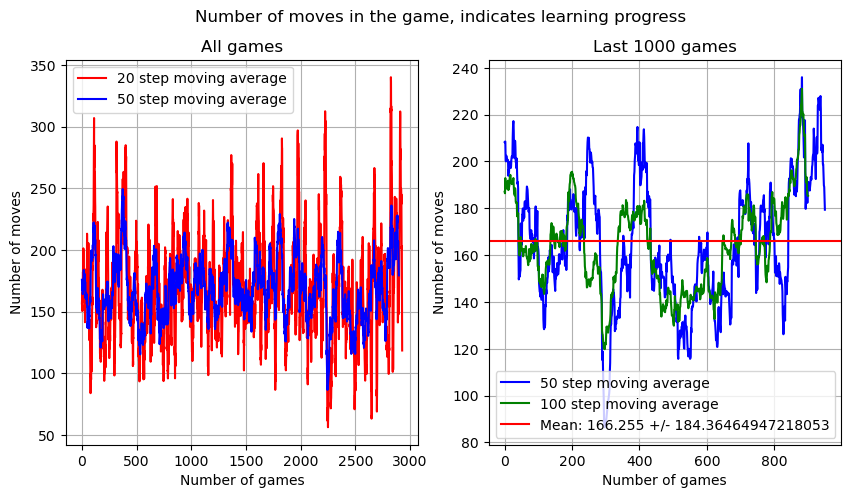

In [19]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# show all
# ax[0].scatter(range(len(env.length_of_games)), env.length_of_games, s=1, alpha=.5)
ax[0].plot(moving_average(env.length_of_games, 20), label='20 step moving average', color='red')
ax[0].plot(moving_average(env.length_of_games, 50), label='50 step moving average', color='blue')
ax[0].set_xlabel('Number of games')
ax[0].set_ylabel('Number of moves')
ax[0].set_title('All games')
ax[0].grid()
ax[0].legend()

# show last 1000
n_last = 1000
# ax[1].scatter(range(len(env.length_of_games[-n_last:])), env.length_of_games[-n_last:], s=1, alpha=.5)
ax[1].plot(moving_average(env.length_of_games[-n_last:], 50), label='50 step moving average', color='blue')
ax[1].plot(moving_average(env.length_of_games[-n_last:], 100), label='100 step moving average', color='green')
ax[1].axhline(y=np.mean(env.length_of_games[-n_last:]), color='red', label=f'Mean: {np.mean(env.length_of_games[-n_last:])} +/- {np.std(env.length_of_games[-n_last:])}')
#generate grey zone for std
#ax[1].fill_between(range(n_last-100), np.mean(env.length_of_games[-n_last:])-np.std(env.length_of_games[-n_last:]), np.mean(env.length_of_games[-n_last:])+np.std(env.length_of_games[-n_last:]), color='grey', alpha=.5)
ax[1].set_xlabel('Number of games')
ax[1].set_ylabel('Number of moves')
ax[1].set_title('Last 1000 games')
ax[1].grid()
ax[1].legend()

plt.suptitle('Number of moves in the game, indicates learning progress')
plt.show()


([<matplotlib.axis.YTick at 0x2a525502e70>,
 [Text(0, 0, 'Up'),
  Text(0, 1, 'Down'),
  Text(0, 2, 'Right'),
  Text(0, 3, 'Left')])

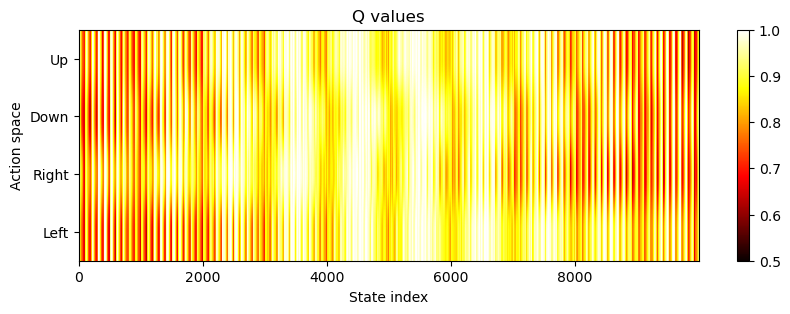

In [21]:
plt.figure(figsize=(10,3))
# plt.imshow((agent1.Q.T-.5)**.1, aspect='auto', cmap='hot')
plt.imshow(agent1.Q.T, aspect='auto', cmap='hot')
plt.colorbar()
plt.title('Q values')
plt.xlabel('State index')
plt.ylabel('Action space')
plt.yticks(range(4), ['Up', 'Down', 'Right', 'Left'])

Text(0.5, 1.0, 'Agent1 last game history, color indicates the order of the move')

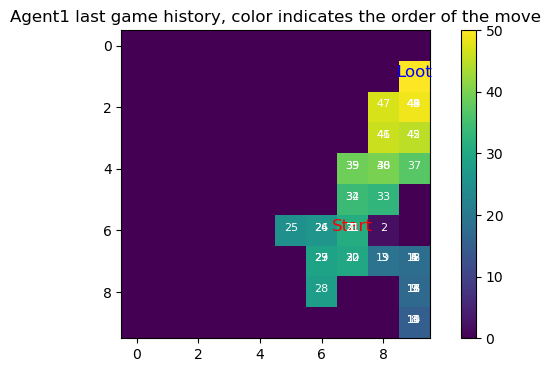

In [22]:
agent1.last_history

# show history on a single imshow
M = np.zeros((env.height, env.width))
path = []
counter = 1
for state, action in agent1.last_history:
    M[env.states[state][1], env.states[state][0]] = counter
    path.append(env.states[state][:2])
    counter += 1
    # break
loot = str(agent1.last_history[0][0])[2:]
lootx, looty = int(loot[0]), int(loot[1])
M[looty, lootx] = counter

plt.figure(figsize=(8,4))
plt.imshow(M, cmap='viridis')
plt.colorbar()
plt.text(lootx, looty, 'Loot', color='blue', fontsize=12, ha='center')
plt.text(int(str(agent1.last_history[0][0])[0]), 
         int(str(agent1.last_history[0][0])[1]), 'Start', color='red', fontsize=12, ha='center')
for i, p in enumerate(path):
    plt.text(p[0], p[1], i+1, color='white', fontsize=8, ha='center')

plt.title('Agent1 last game history, color indicates the order of the move')

## Next steps:
* Expand specification at the top of the file
* Insert barriers/blocked spaces
* Update Q learning formula. Currently it rewards last 20 steps equally
* Add second player
* Switch to DQNs
    * Why does it make sense to use DQN? -> The state vector, can be passed through a little function which instead of containing the 4 coordinates, is just expressed as an angle to the loot. This way, the agent can learn to move towards the loot, and not just in a direction.